In [1]:
import pandas as pd
import numpy as np

### Loading the data and short preview

In [2]:
data = pd.read_csv('C:\\Users\\Администратор\\Documents\\study\\APS\\data\\processed_dataset_updated.csv')
print("DataFrame Shape:", data.shape)

DataFrame Shape: (191148, 154)


In [3]:
data.columns.tolist()

['Unnamed: 0',
 'id',
 'referral_date',
 'open_date',
 'closed_date',
 'number_of_days_open',
 'disposition_status_description',
 'deny_reason_desc',
 'closure_desc',
 'prior_aps_history_before_2022',
 'age_at_time_of_referral',
 'gender',
 'race',
 'marital_status_description',
 'veteran_ind',
 'housing_arrangement',
 'does_client_live_alone',
 'alleged_harm_vs_confirmed_harm',
 'alleged_harm_self_neglect',
 'unnamed:_18',
 'investigation_harm_self_neglect',
 'alleged_harm_neglect',
 'investigation_harm_neglect',
 'alleged_harm_financial_exploitation',
 'investigation_harm_financial_exploitation',
 'alleged_harm_exploitation_of_person',
 'investigation_harm_exploitation_of_person',
 'alleged_harm_physical_abuse',
 'investigation_harm_physical_abuse',
 'alleged_harm_emotional_abuse',
 'investigation_harm_emotional_abuse',
 'alleged_harm_sexual_abuse',
 'investigation_harm_sexual_abuse',
 'alleged_harm_abandonment',
 'investigation_harm_abandonment',
 'unnamed:_34',
 'alleged_v_verified

These are the columns that were added to the original dataset:
   -  _'duration'_,
   - _'main_id'_,
   - _'first_open_date'_,
   - _'time_since_first_open'_,
   - _'first_open_0_6_months'_,
   - _'first_open_6_12_months'_,
   - _'first_open_12_24_months'_,
   - _'first_open_more_24_months'_,
   - _'total_case_count'_.

In [4]:
def quick_view(df):
    print("DataFrame Shape:", df.shape)

    print(f'\n Data types:\n{df.dtypes.value_counts()} \n')

    print(f'\n Duplicate rows: {df.duplicated().sum()}')

quick_view(data)

DataFrame Shape: (191148, 154)

 Data types:
object     133
float64     14
bool         4
int64        3
Name: count, dtype: int64 


 Duplicate rows: 0


In [5]:
data.head()

,Unnamed: 0,id,referral_date,open_date,closed_date,number_of_days_open,disposition_status_description,deny_reason_desc,closure_desc,prior_aps_history_before_2022,...,perpetrator_closing_risk_mental_emotional_health_control_over_client,duration,main_id,first_open_date,time_since_first_open,first_open_0_6_months,first_open_6_12_months,first_open_12_24_months,first_open_more_24_months,total_case_count
0,0,987679398-1,2024-03-29,NaN,NaN,NaN,DENIED,Client has not been harmed and is not at risk ...,NaN,Y,...,NaN,NaN,987679398,2024-09-04,NaN,False,False,False,False,2
1,1,987679398-2,2024-09-04,2024-09-04,2024-09-19,15.0,CLOSED,NaN,Services Not Available,Y,...,1,15 days,987679398,2024-09-04,0.0,False,False,False,False,2
2,2,987679482-1,2022-03-01,2022-03-01,2022-04-15,45.0,CLOSED,NaN,Situation stable,N,...,2,45 days,987679482,2022-03-01,0.0,False,False,False,False,10
3,3,987679482-2,2022-03-04,NaN,NaN,NaN,DENIED,Duplicate referral/no new allegations/new refe...,NaN,N,...,NaN,NaN,987679482,2022-03-01,NaN,False,False,False,False,10
4,4,987679482-3,2023-02-13,2023-02-13,2023-04-13,59.0,CLOSED,NaN,Situation stable,N,...,1,59 days,987679482,2022-03-01,349.0,False,True,False,False,10


In [6]:
data.columns.to_list()

['Unnamed: 0',
 'id',
 'referral_date',
 'open_date',
 'closed_date',
 'number_of_days_open',
 'disposition_status_description',
 'deny_reason_desc',
 'closure_desc',
 'prior_aps_history_before_2022',
 'age_at_time_of_referral',
 'gender',
 'race',
 'marital_status_description',
 'veteran_ind',
 'housing_arrangement',
 'does_client_live_alone',
 'alleged_harm_vs_confirmed_harm',
 'alleged_harm_self_neglect',
 'unnamed:_18',
 'investigation_harm_self_neglect',
 'alleged_harm_neglect',
 'investigation_harm_neglect',
 'alleged_harm_financial_exploitation',
 'investigation_harm_financial_exploitation',
 'alleged_harm_exploitation_of_person',
 'investigation_harm_exploitation_of_person',
 'alleged_harm_physical_abuse',
 'investigation_harm_physical_abuse',
 'alleged_harm_emotional_abuse',
 'investigation_harm_emotional_abuse',
 'alleged_harm_sexual_abuse',
 'investigation_harm_sexual_abuse',
 'alleged_harm_abandonment',
 'investigation_harm_abandonment',
 'unnamed:_34',
 'alleged_v_verified

#### Filtering before the Preprocessing

In [7]:
# Removing the Refferal Only Cases
df = data[data['open_date'].notna()]
print(f'original shape: {data.shape}')
print(f'new shape: {df.shape}')

original shape: (191148, 154)
new shape: (78559, 154)


In [8]:
# Identify any column that starts with 'Unnamed'
unnamed_cols = [col for col in df.columns if 'nnamed' in col]

# Drop them from the dataframe
df = df.drop(columns=unnamed_cols)

print(f"Dropped {len(unnamed_cols)} columns: {unnamed_cols}")
print(f"New shape: {df.shape}")

Dropped 5 columns: ['Unnamed: 0', 'unnamed:_18', 'unnamed:_34', 'unnamed:_38', 'unnamed:_113']
New shape: (78559, 149)


**The missing values were signed as question mark in the excel file, so I decided to convert them into NaN values**

In [9]:
df = df.replace('?', np.nan) # Replace '?' with NaN
df.isnull().sum()

id                            0
referral_date                 0
open_date                     0
closed_date                  36
number_of_days_open          36
                             ..
first_open_0_6_months         0
first_open_6_12_months        0
first_open_12_24_months       0
first_open_more_24_months     0
total_case_count              0
Length: 149, dtype: int64

In [10]:
# Automatically drop any column where 100% of the data is missing
df = df.dropna(axis=1, how='all')

print(f"New shape after dropping empty columns: {df.shape}")

df.isnull().sum().sort_values(ascending=False).head(20)

New shape after dropping empty columns: (78559, 141)


does_client_live_alone                                                                19138
marital_status_description                                                            17271
race                                                                                   3899
age_at_time_of_referral                                                                1650
environmental_closing_risk_inadequate_food_supplies                                    1120
client_closing_risk_confusion_over_medications                                         1120
client_closing_risk_confused                                                           1120
environmental_closing_risk_homelessness                                                1120
client_closing_risk_lacks_or_refuses_needed_medical_care_or_treatment                  1120
client_closing_risk_current_alcohol_or_substance_abuse                                 1120
environmental_closing_risk_lacks_utilities_electric_water_heat                  

#### Prevention of Data Leakage

Right now, the dataset still contains all those closing_risk columns and closure descriptions. If you look at those while trying to predict the future, it's like having the answers to a test before you take it.

In [11]:
# REMOVE THE DATA LEAKAGE COLUMNS
# 1. Identify all the columns that happen at the END of a case
closing_cols = [col for col in df.columns if 'closing' in col.lower() or 'closure' in col.lower() or 'closed' in col.lower()]

# 2. Create the "Vault" (keeping the IDs so you don't lose track of who is who)
df_closing = df[['id', 'main_id'] + closing_cols]

# 3. Create your safe Working Data by dropping those closing columns
df_model = df.drop(columns=closing_cols)

# 4. Let's see how much cleaner it is!
print(f"Original columns: {df.shape[1]}")
print(f"Safe Working columns: {df_model.shape[1]}")

Original columns: 141
Safe Working columns: 96


In [12]:
print(f"Original columns: {data.shape[1]}")
print(f"Safe Working columns: {df_model.shape[1]}")

Original columns: 154
Safe Working columns: 96


In [13]:
df_model['closed_date'] = df_closing['closed_date'] # Add the closed_date back to the model dataframe for target variable

# df_model.columns.tolist()

In [14]:
# Dictionary mapping the old names to new names
# the old names were too long and not intuitive, so I am renaming them to be more concise and clear
rename_dict = {
    'first_open_0_6_months': 'reoccurred_6m',
    'first_open_6_12_months': 'reoccurred_6_12m',
    'first_open_12_24_months': 'reoccurred_12_24m',
    'first_open_more_24_months': 'reoccurred_24m_plus'
}

# Apply the renaming to your working dataframe
df_model = df_model.rename(columns=rename_dict)


#### First Feature Categorization

In [15]:
# 1. TARGETS & TIMELINE
target_cols = [
    'reoccurred_6m', 'reoccurred_6_12m', 
    'reoccurred_12_24m', 'reoccurred_24m_plus'
]
timeline_cols = [
    'referral_date', 'open_date', 'first_open_date', 
    'time_since_first_open', 'duration', 'number_of_days_open', 'total_case_count'
]

# 2. CLIENT DEMOGRAPHICS & HISTORY
demo_cols = [
    'age_at_time_of_referral', 'gender', 'race', 
    'marital_status_description', 'veteran_ind', 'housing_arrangement', 
    'does_client_live_alone', 'prior_aps_history_before_2022'
]

# 3. ALLEGATIONS & VULNERABILITIES
# What was reported and the client's baseline vulnerabilities
harm_and_vuln_cols = [col for col in df_model.columns if 'harm' in col or 'vulnerability' in col]

# 4. INITIAL RISKS - CLIENT
# The physical/mental state of the client at intake
client_risk_cols = [col for col in df_model.columns if 'client_intial_risk' in col]

# 5. INITIAL RISKS - ENVIRONMENTAL
env_risk_cols = [col for col in df_model.columns if 'environmental_intial_risk' in col]

# 6. INITIAL RISKS - SUPPORT, CAREGIVER & PERPETRATOR 
# The social network and potential bad actors at intake
support_caregiver_cols = [col for col in df_model.columns if 'support_network_intial' in col or 'caregiver_intial' in col or 'perpetrator_intial' in col]
support_caregiver_cols.extend(['live_with_ind', 'primary_caregiver_ind', 'perpetrator_type_desc'])

print("Feature lists categorized successfully!")
# Print a quick summary to ensure everything mapped correctly
print(f"Targets: {len(target_cols)}")
print(f"Timeline: {len(timeline_cols)}")
print(f"Demographics & History: {len(demo_cols)}")
print(f"Harm/Vuln: {len(harm_and_vuln_cols)}")
print(f"Client Risks: {len(client_risk_cols)}")
print(f"Env Risks: {len(env_risk_cols)}")
print(f"Support/Caregiver Risks: {len(support_caregiver_cols)}")

Feature lists categorized successfully!
Targets: 4
Timeline: 7
Demographics & History: 8
Harm/Vuln: 28
Client Risks: 14
Env Risks: 9
Support/Caregiver Risks: 23


In [16]:
# The crucial ID columns
id_cols = ['id', 'main_id']

# The investigation status
investigation_cols = ['disposition_status_description']

# Let's do a final check!
total_categorized = len(target_cols + timeline_cols + demo_cols + 
                        harm_and_vuln_cols + client_risk_cols + 
                        env_risk_cols + support_caregiver_cols + 
                        id_cols + investigation_cols)

print(f"Total columns accounted for: {total_categorized} / {df_model.shape[1]}")

Total columns accounted for: 96 / 97


In [28]:
# Missingess Analysis

# 1. Calculate pure missingness (NaNs only)
missing_df = df_model.isnull().sum().reset_index()
missing_df.columns = ['Feature', 'Missing_Count']

# 2. Calculate the percentage
missing_df['%_Missing'] = round((missing_df['Missing_Count'] / len(df_model)) * 100, 2)

# 3. Filter to show ONLY columns with actual missing data, sorted highest to lowest
pure_missing_report = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='%_Missing', ascending=False)

print(f"Total columns with missing data: {len(pure_missing_report)}")
print("\n--- STRICT MISSING DATA (NaN) REPORT ---")
display(pure_missing_report)

Total columns with missing data: 60

--- STRICT MISSING DATA (NaN) REPORT ---


,Feature,Missing_Count,%_Missing
12,does_client_live_alone,19138,24.36
9,marital_status_description,17271,21.98
8,race,3899,4.96
6,age_at_time_of_referral,1650,2.10
59,environmental_intial_risk_evidence_of_hoarding...,610,0.78
68,support_network_intial_risk_lack_access_to_com...,610,0.78
58,environmental_intial_risk_barriers_to_access,610,0.78
60,environmental_intial_risk_homelessness,610,0.78
61,environmental_intial_risk_inadequate_food_supp...,610,0.78
62,environmental_intial_risk_lacks_utilities_elec...,610,0.78


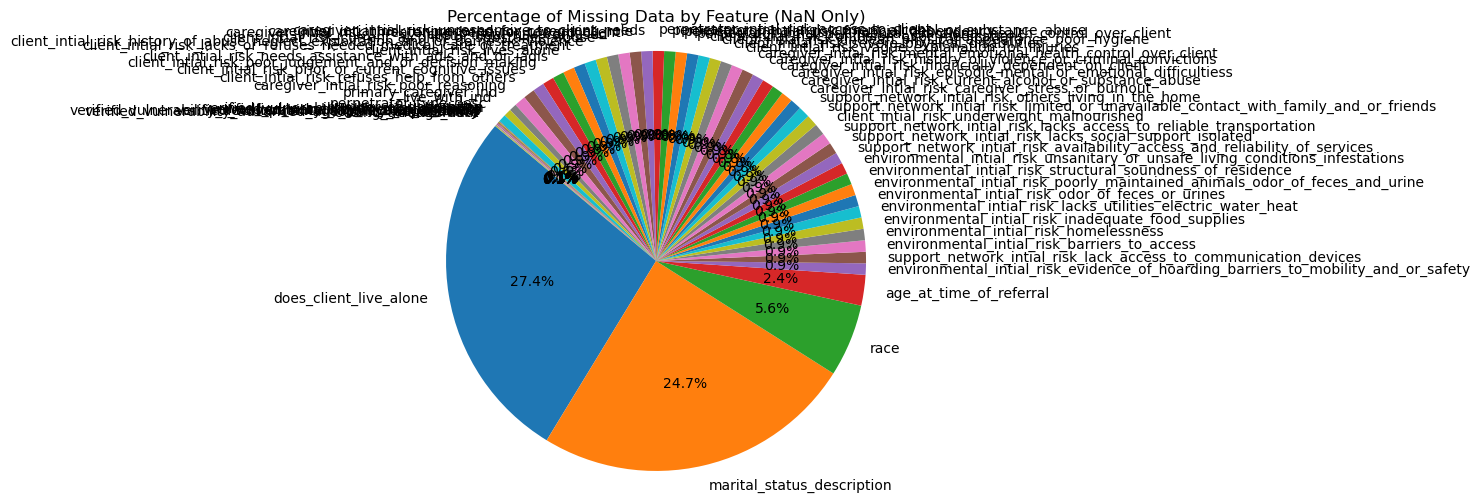

In [33]:
# visualize the missingness
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.pie(pure_missing_report['%_Missing'], labels=pure_missing_report['Feature'], autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Missing Data by Feature (NaN Only)')
plt.axis('equal')
plt.show()

C:\Users\Администратор\AppData\Local\Temp\ipykernel_8276\2267081294.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


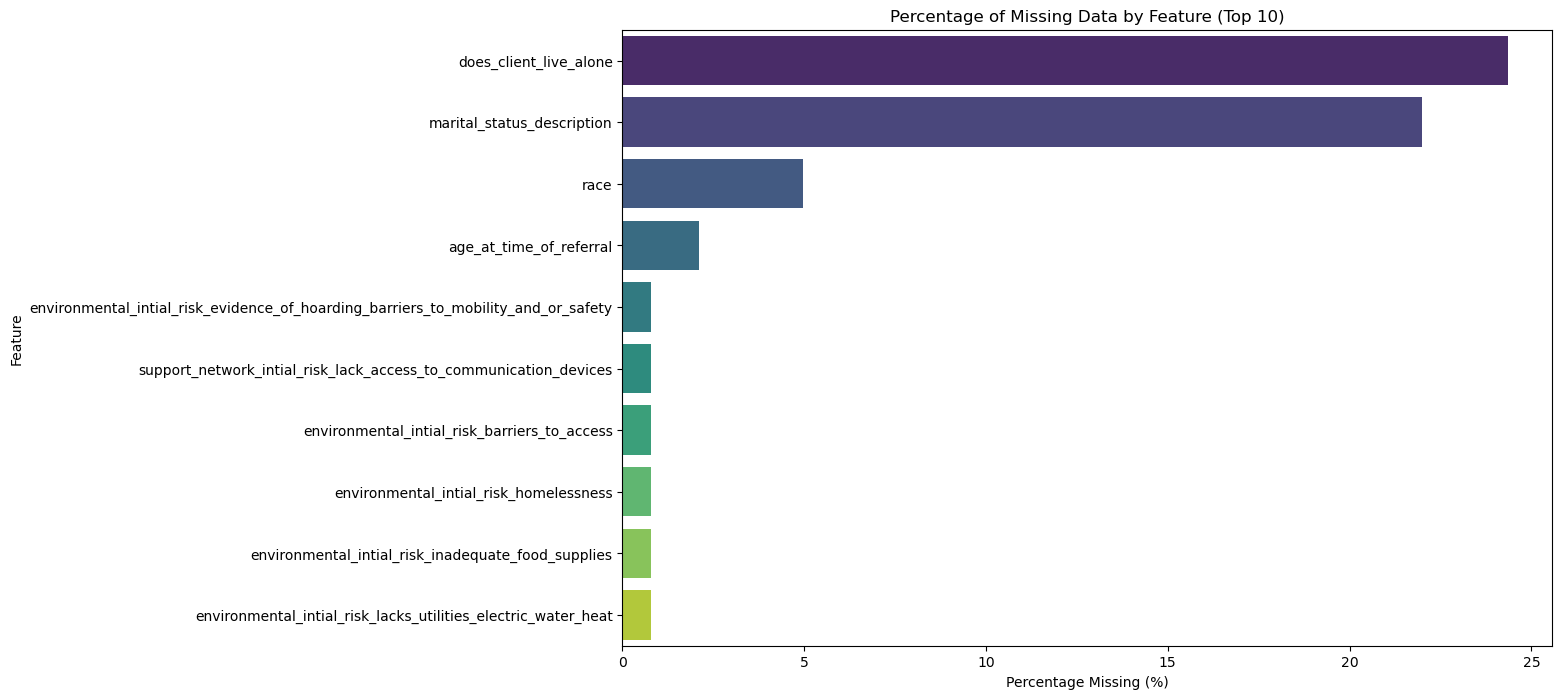

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn makes bar charts look much cleaner

plt.figure(figsize=(12, 8))
# Using seaborn to plot the top 10 missing features to avoid a cluttered graph
sns.barplot(
    data=pure_missing_report.head(10), 
    x='%_Missing', 
    y='Feature', 
    palette='viridis'
)

plt.title('Percentage of Missing Data by Feature (Top 10)')
plt.xlabel('Percentage Missing (%)')
plt.ylabel('Feature')
plt.show()

In [30]:
pure_missing_report.head(10)

,Feature,Missing_Count,%_Missing
12,does_client_live_alone,19138,24.36
9,marital_status_description,17271,21.98
8,race,3899,4.96
6,age_at_time_of_referral,1650,2.10
59,environmental_intial_risk_evidence_of_hoarding...,610,0.78
68,support_network_intial_risk_lack_access_to_com...,610,0.78
58,environmental_intial_risk_barriers_to_access,610,0.78
60,environmental_intial_risk_homelessness,610,0.78
61,environmental_intial_risk_inadequate_food_supp...,610,0.78
62,environmental_intial_risk_lacks_utilities_elec...,610,0.78


#### Do the missingness correlate with each other?

--- 1. CORRELATION OF MISSINGNESS ---


,does_client_live_alone,marital_status_description,race,age_at_time_of_referral
does_client_live_alone,1.000000,0.030400,0.014221,0.029580
marital_status_description,0.030400,1.000000,0.138384,0.071860
race,0.014221,0.138384,1.000000,0.032743
age_at_time_of_referral,0.029580,0.071860,0.032743,1.000000


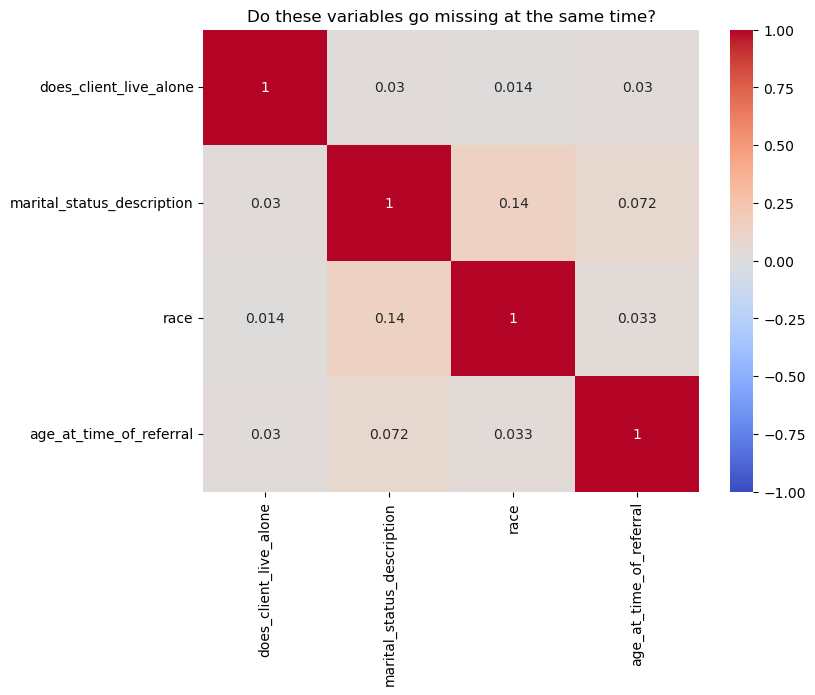


--- 2. DOES MISSING DATA AFFECT 6-MONTH REOCCURRENCE? ---
Average Reoccurrence Rate (%):
Has Marital Status Data        5.82
Missing Marital Status Data    4.33
Name: reoccurred_6m, dtype: float64


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Focus purely on the demographics with gaps
demo_gaps = ['does_client_live_alone', 'marital_status_description', 'race', 'age_at_time_of_referral']

# 2. Create a "shadow matrix" (True if the data is missing, False if it is present)
missing_shadow = df_model[demo_gaps].isnull()

# 3. Calculate the correlation of the missingness
missing_corr = missing_shadow.corr()

print("--- 1. CORRELATION OF MISSINGNESS ---")
display(missing_corr)

# 4. Visual Heatmap (Makes it easy to read!)
plt.figure(figsize=(8, 6))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Do these variables go missing at the same time?")
plt.show()

# 5. The Ultimate Test: Does missing data change the Reoccurrence Rate?
# We group by whether Marital Status is missing, and look at the average Reoccurrence
print("\n--- 2. DOES MISSING DATA AFFECT 6-MONTH REOCCURRENCE? ---")
target_check = df_model.groupby(missing_shadow['marital_status_description'])['reoccurred_6m'].mean() * 100
target_check.index = ['Has Marital Status Data', 'Missing Marital Status Data']
print("Average Reoccurrence Rate (%):")
print(round(target_check, 2))

Checking missingness for: ['environmental_intial_risk_poorly_maintained_animals_odor_of_feces_and_urine', 'environmental_intial_risk_structural_soundness_of_residence', 'support_network_intial_risk_availability_access_and_reliability_of_services', 'support_network_intial_risk_lack_access_to_communication_devices', 'support_network_intial_risk_lacks_access_to_reliable_transportation']



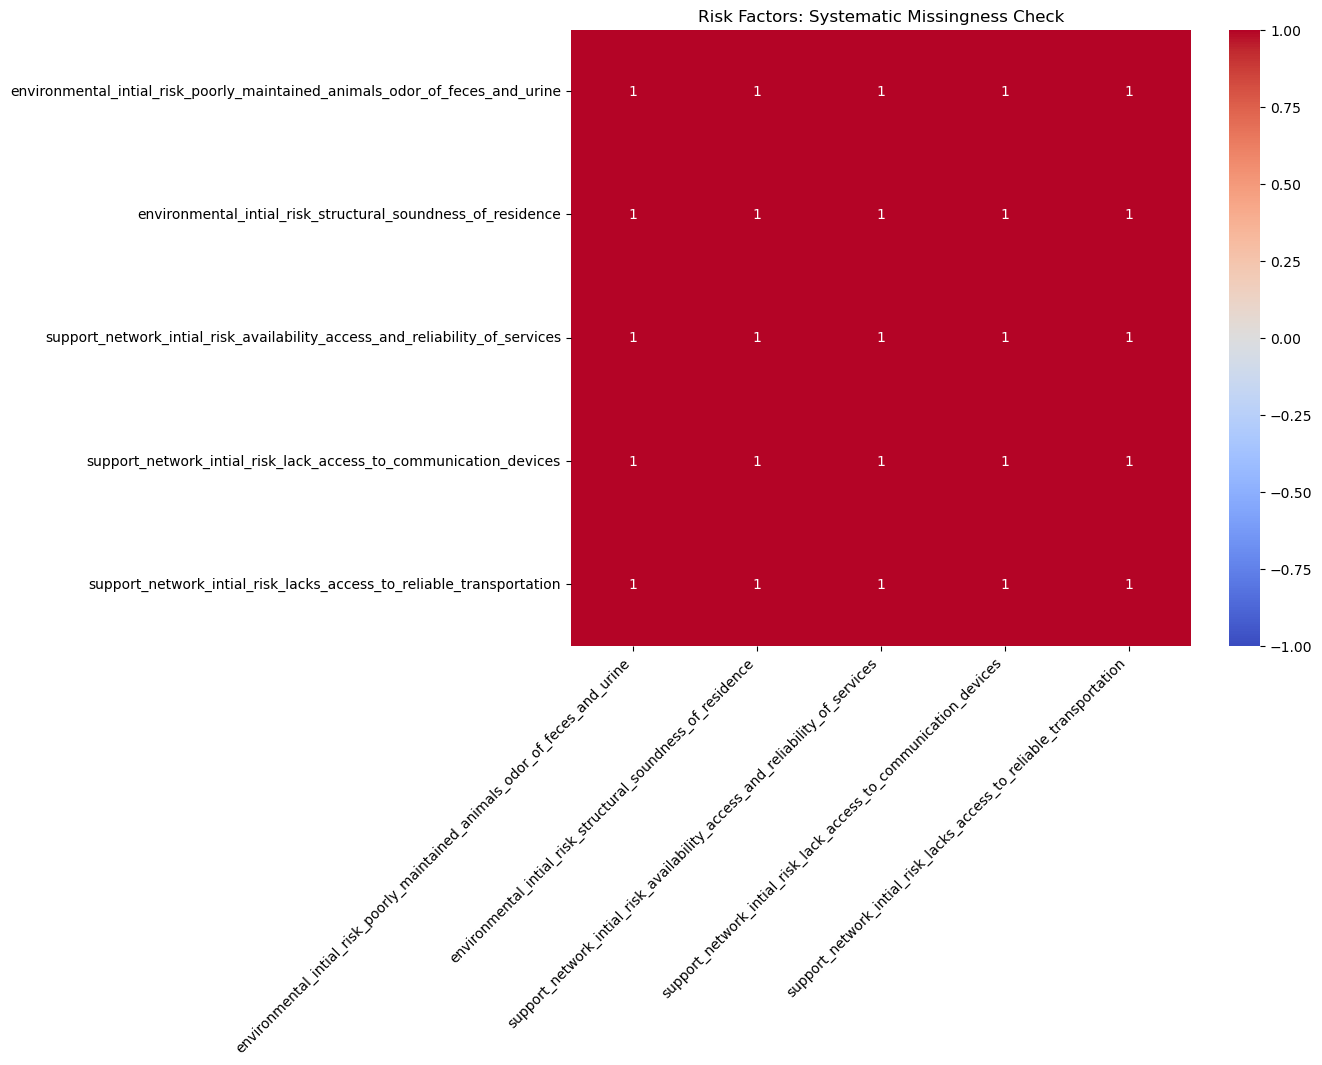

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dynamically find the risk columns that have missing data
all_risk_cols = client_risk_cols + env_risk_cols + support_caregiver_cols
risk_cols_with_gaps = [col for col in all_risk_cols if df_model[col].isnull().sum() > 0]

# 2. Grab just the top 5 to keep the heatmap readable
# (Using the missing_df you generated earlier)
top_risk_gaps = missing_df[missing_df['Feature'].isin(risk_cols_with_gaps)].sort_values(by='Missing_Count', ascending=False).head(5)['Feature'].tolist()

print(f"Checking missingness for: {top_risk_gaps}\n")

# 3. Create the shadow matrix
risk_shadow = df_model[top_risk_gaps].isnull()
risk_corr = risk_shadow.corr()

# 4. Visual Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(risk_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Risk Factors: Systematic Missingness Check")
# Angling the labels so they don't overlap
plt.xticks(rotation=45, ha='right') 
plt.show()



In [21]:
# Since they are perfectly correlated (1.0), dropping NaNs based on one column drops them all.
# sample_risk_col = top_risk_gaps[0]
# df_model = df_model.dropna(subset=[sample_risk_col])

From a domain perspective, this makes total sense! If a situation is so chaotic, hostile, or uncooperative that the APS worker can't even complete the standard risk checklist, that client is probably at a higher risk of needing intervention again soon.

In [22]:
df_model[harm_and_vuln_cols].head()

,alleged_harm_self_neglect,investigation_harm_self_neglect,alleged_harm_neglect,investigation_harm_neglect,alleged_harm_financial_exploitation,investigation_harm_financial_exploitation,alleged_harm_exploitation_of_person,investigation_harm_exploitation_of_person,alleged_harm_physical_abuse,investigation_harm_physical_abuse,...,alleged_vulnerability_developmental_intellectual_disability,alleged_vulnerability_medically_fragile,alleged_vulnerability_mental_illness,alleged_vulnerability_physical_disability,verified_vulnerability_advanced_age_frailty_dependency,verified_vulnerability_cognitive_impairment,verified_vulnerability_developmental_intellectual_disability,verified_vulnerability_medically_fragile,verified_vulnerability_mental_illness,verified_vulnerability_physical_disability
1,N,Not Applicable,Y,Unsubstantiated,N,Not Applicable,N,Not Applicable,N,Not Applicable,...,N,Y,N,Y,Y,N,N,N,N,N
2,Y,Unsubstantiated,Y,Unsubstantiated,N,Not Applicable,N,Not Applicable,N,Not Applicable,...,N,N,N,N,N,N,N,N,N,Y
4,Y,Unsubstantiated,N,Not Applicable,N,Not Applicable,N,Not Applicable,N,Not Applicable,...,N,N,Y,Y,N,N,N,N,N,Y
9,N,Not Applicable,Y,Unsubstantiated,N,Not Applicable,N,Not Applicable,N,Not Applicable,...,N,N,Y,Y,N,N,N,N,N,Y
15,N,Not Applicable,Y,Substantiated,N,Not Applicable,N,Not Applicable,N,Not Applicable,...,Y,Y,N,Y,N,N,N,N,Y,Y


In [23]:
pd.DataFrame.to_csv(df_model, 'df_model_aps_data.csv', index=False)

In [24]:
# pd.DataFrame.to_csv(df_model[demo_cols], 'demographics.csv', index=False)

In [25]:
# 1. Let's see if missingness in these risk factors are MNAR, MAR or MNAR by checking if the target variable (reoccurrence) is different when the data is missing vs. when it is present.

# is_missing_marital = df_model['marital_status_description'].isnull()

# age_comparison = df_model.groupby(is_missing_marital)['age_at_time_of_referral'].mean()
# age_comparison.index = ['Has Marital Status Data', 'Missing Marital Status Data']
# print("Average Age at Referral:")
# print(round(age_comparison, 1))

# df_model['age_at_time_of_referral'].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

([<matplotlib.patches.Wedge at 0x1d3c2d54c80>,
 [Text(-1.0976062423828095, 0.07252955730106989, 'Has Age Data'),
  Text(1.097606246202581, -0.07252949949558073, 'Missing Age Data')],
 [Text(-0.5986943140269869, 0.03956157670967448, '97.9%'),
  Text(0.5986943161104986, -0.039561545179407666, '2.1%')])

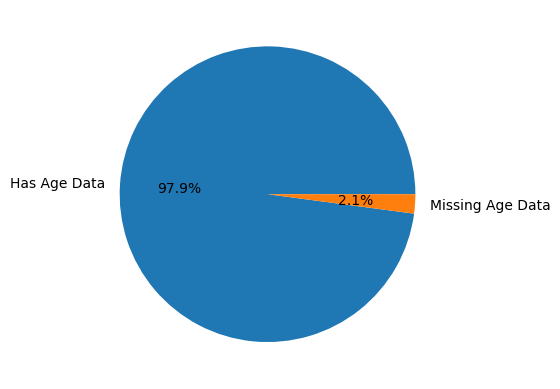

In [26]:
# HOT DECK IMPUTATION
plt.pie(df_model['age_at_time_of_referral'].isnull().value_counts(), labels=['Has Age Data', 'Missing Age Data'], autopct='%1.1f%%')

In [27]:
# new_df = df_model[['id', 'open_date', 'closed_date', 'number_of_days_open']]

# pd.DataFrame.to_csv(new_df, 'case_timeline.csv', index=False)

# """
# id (case ID, formatted as personID-caseNumber, e.g., 987679482-1)
# referral_date
# open_date
# closed_date
# number_of_days_open
# """